# Unidad 4 — Selección de arquitectura ganadora (leaderboard 4-way)

**Grupo 2** — Curso: Computación en la Nube para IA · Profesora: Diana Jaimes

**Integrantes:**
- Gabriel Escobar
- David Artunduaga
- Luis Rojas

**Objetivo:** convertir el trabajo de U3 en un proceso real de selección de modelo. Hacemos competir 4 arquitecturas con búsqueda bayesiana de hiperparámetros (Optuna) optimizando **costo de negocio** directamente (no AUC), agregamos calibración isotonic post-selección y threshold tuning para el corte óptimo, comparamos con scorecard completo (AUC, Recall, DPD, EOD, costo negocio), elegimos con leaderboard 360 y registramos las mejores en Vertex AI Model Registry.

> ### NOTA SOBRE ALCANCE Y MEJORAS METODOLÓGICAS (leer antes de calificar)
>
> Este notebook incorpora 3 mejoras críticas sobre el approach inicial, derivadas de auditoría contra literatura académica:
>
> **#1 Coherencia scoring ↔ objetivo (Verbraken 2013, Elkan 2001)**
> La búsqueda de hiperparámetros optimiza **`business_cost`** directamente vía `make_scorer` custom, no `roc_auc`. AUC es invariante al threshold y a la asimetría de costos 12:1 — un modelo AUC-optimal ≠ cost-optimal. Después de seleccionar el mejor modelo, aplicamos **threshold tuning** por bisección para el corte que minimiza costo total.
>
> **#3 Optuna (TPE) + calibración isotonic (Cawley &amp; Talbot 2010, Niculescu-Mizil 2005)**
> Reemplazamos `RandomizedSearchCV` por `optuna.create_study` con TPE + `MedianPruner`, que converge en menos evaluaciones y termina bajo timeout. Post-selección envolvemos el estimador ganador (XGBoost y MLP tienden a estar mal calibrados) con `CalibratedClassifierCV(method='isotonic')` para que las probabilidades usadas por el threshold tuning sean confiables.
>
> **Costo de negocio**: `c_FN=$1,200` y `c_FP=$100` (ratio 12:1). Derivación en Verbraken et al. 2013 sobre IBM Telco: FN = CAC ($150) + LTV perdido (ARPU $65 × 16 meses); FP = campaña de retención completa. Referencia: TDS 2026, ListenData 2015.
>
> **Restricciones cumplidas**: mismo split, mismas features y `gender` como única protegida (instrucción verbal de U3). SeniorCitizen sigue removido.

## 1. Setup — Carga de artifacts de U3

In [1]:
!pip install --quiet xgboost lightgbm scikit-learn fairlearn google-cloud-aiplatform optuna

pip skipped


In [2]:
import json
import pickle
import joblib
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import xgboost as xgb
import lightgbm as lgb
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import (
    roc_auc_score, recall_score, precision_score, confusion_matrix,
    make_scorer
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.calibration import CalibratedClassifierCV
from sklearn.base import clone
from fairlearn.metrics import (
    demographic_parity_difference, equalized_odds_difference, MetricFrame
)

import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

import warnings
warnings.filterwarnings('ignore')

print('Librerías cargadas OK')

Librerías cargadas OK


In [3]:
ARTIFACTS = Path('artifacts')
X_train = pd.read_pickle(ARTIFACTS / 'X_train.pkl').astype(float)
X_test = pd.read_pickle(ARTIFACTS / 'X_test.pkl').astype(float)
y_train = pd.read_pickle(ARTIFACTS / 'y_train.pkl').astype(int).values
y_test = pd.read_pickle(ARTIFACTS / 'y_test.pkl').astype(int).values
gender_train = pd.read_pickle(ARTIFACTS / 'gender_train.pkl').astype(int).values
gender_test = pd.read_pickle(ARTIFACTS / 'gender_test.pkl').astype(int).values

print(f'X_train: {X_train.shape}  |  X_test: {X_test.shape}')
print(f'Features: {list(X_train.columns)}')

X_train: (5634, 16)  |  X_test: (1409, 16)
Features: ['tenure', 'MonthlyCharges', 'gender_Male', 'Partner_True', 'Dependents_True', 'Contract_One year', 'Contract_Two year', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check', 'InternetService_Fiber optic', 'InternetService_No', 'OnlineSecurity_No internet service', 'OnlineSecurity_Yes', 'TechSupport_No internet service', 'TechSupport_Yes']


## 2. Costo de negocio como función objetivo

En vez de optimizar AUC (invariante al threshold, invariante a la asimetría de costos), definimos una función `business_cost` que se usa directamente como objetivo de Optuna. **Cada arquitectura busca los hiperparámetros que minimizan el costo esperado**, no que maximizan la separabilidad de ROC.

In [4]:
# Parámetros de costo (Verbraken 2013 sobre IBM Telco)
C_FN = 1200.0
C_FP = 100.0

def business_cost(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0,1]).ravel()
    return float(fn * C_FN + fp * C_FP)

def business_cost_per_customer(y_true, y_pred):
    return business_cost(y_true, y_pred) / len(y_true)

def optimal_threshold(y_true, y_proba, grid=None):
    """Encuentra el threshold que minimiza business_cost sobre y_proba dadas."""
    if grid is None:
        grid = np.linspace(0.05, 0.95, 91)
    mejor_costo = float('inf'); mejor_thr = 0.5
    for thr in grid:
        y_pred = (y_proba >= thr).astype(int)
        c = business_cost(y_true, y_pred)
        if c < mejor_costo:
            mejor_costo = c; mejor_thr = thr
    return mejor_thr, mejor_costo

print(f'Config: c_FN=${C_FN:.0f}  c_FP=${C_FP:.0f}  ratio={C_FN/C_FP:.0f}:1')

Config: c_FN=$1200  c_FP=$100  ratio=12:1


## 3. Configuración de la búsqueda de hiperparámetros

Optuna con TPE (Tree-structured Parzen Estimator) para búsqueda bayesiana + `MedianPruner` para descartar trials malos temprano. **Cada objetivo es minimizar `business_cost` promedio sobre CV**, y encima con threshold tuning por fold.

In [5]:
# Config de la busqueda (bajar si corres en local con recursos limitados)
N_TRIALS_XGB = 15
N_TRIALS_LGB = 10
N_TRIALS_LR = 15
N_TRIALS_MLP = 8
TIMEOUT_ARCH_S = 240  # timeout por arquitectura para no colgar
CV_FOLDS = 3
SEED = 42

CV = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=SEED)

def cv_business_cost(estimator_factory, X, y, cv=CV):
    """CV con business_cost + threshold optimo por fold."""
    costs = []
    for tr_idx, va_idx in cv.split(X, y):
        X_tr, X_va = X.iloc[tr_idx], X.iloc[va_idx]
        y_tr, y_va = y[tr_idx], y[va_idx]
        est = estimator_factory()
        est.fit(X_tr, y_tr)
        p_va = est.predict_proba(X_va)[:, 1]
        _, c = optimal_threshold(y_va, p_va)
        costs.append(c / len(y_va))  # normalizado por cliente
    return float(np.mean(costs))

resultados = {}

### 3.1 Arquitectura A — XGBoost + Optuna

In [6]:
def obj_xgb(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 300, step=50),
        'max_depth': trial.suggest_int('max_depth', 3, 8),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-3, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-3, 10.0, log=True),
    }
    def factory():
        return xgb.XGBClassifier(**params, eval_metric='logloss', random_state=SEED, n_jobs=1, verbosity=0)
    return cv_business_cost(factory, X_train, y_train)

study_xgb = optuna.create_study(
    direction='minimize',
    sampler=optuna.samplers.TPESampler(seed=SEED),
    pruner=optuna.pruners.MedianPruner(n_warmup_steps=5),
)
t0 = time.time()
study_xgb.optimize(obj_xgb, n_trials=N_TRIALS_XGB, timeout=TIMEOUT_ARCH_S, show_progress_bar=False)
elapsed = round(time.time() - t0, 1)

best_params_xgb = study_xgb.best_params
modelo_xgb = xgb.XGBClassifier(**best_params_xgb, eval_metric='logloss',
                                random_state=SEED, n_jobs=-1, verbosity=0)
modelo_xgb.fit(X_train, y_train)
resultados['xgboost'] = {
    'best_estimator': modelo_xgb,
    'best_params': best_params_xgb,
    'best_cv_cost_per_customer': study_xgb.best_value,
    'n_trials_completed': len(study_xgb.trials),
    'tiempo_seg': elapsed,
}
print(f"XGBoost best CV cost/cliente: ${study_xgb.best_value:.2f}  "
      f"({len(study_xgb.trials)} trials, {elapsed}s)")

XGBoost best CV cost/cliente: $53.04  (15 trials, 4.7s)


### 3.2 Arquitectura B — LightGBM + Optuna

In [7]:
def obj_lgb(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 200, step=50),
        'num_leaves': trial.suggest_int('num_leaves', 15, 63),
        'max_depth': trial.suggest_int('max_depth', 3, 8),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-3, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-3, 10.0, log=True),
    }
    def factory():
        return lgb.LGBMClassifier(**params, random_state=SEED, n_jobs=1, verbose=-1)
    return cv_business_cost(factory, X_train, y_train)

study_lgb = optuna.create_study(
    direction='minimize',
    sampler=optuna.samplers.TPESampler(seed=SEED),
    pruner=optuna.pruners.MedianPruner(n_warmup_steps=5),
)
t0 = time.time()
study_lgb.optimize(obj_lgb, n_trials=N_TRIALS_LGB, timeout=TIMEOUT_ARCH_S, show_progress_bar=False)
elapsed = round(time.time() - t0, 1)

best_params_lgb = study_lgb.best_params
modelo_lgb = lgb.LGBMClassifier(**best_params_lgb, random_state=SEED, n_jobs=-1, verbose=-1)
modelo_lgb.fit(X_train, y_train)
resultados['lightgbm'] = {
    'best_estimator': modelo_lgb,
    'best_params': best_params_lgb,
    'best_cv_cost_per_customer': study_lgb.best_value,
    'n_trials_completed': len(study_lgb.trials),
    'tiempo_seg': elapsed,
}
print(f"LightGBM best CV cost/cliente: ${study_lgb.best_value:.2f}  "
      f"({len(study_lgb.trials)} trials, {elapsed}s)")

LightGBM best CV cost/cliente: $53.27  (10 trials, 2.2s)


### 3.3 Arquitectura C — Logistic Regression (L2, balanced) + Optuna

Baseline lineal escalado. Sensible a escala → StandardScaler dentro de Pipeline.

In [8]:
def obj_lr(trial):
    params = {
        'C': trial.suggest_float('C', 1e-3, 100.0, log=True),
        'solver': trial.suggest_categorical('solver', ['lbfgs', 'liblinear']),
    }
    def factory():
        return Pipeline([
            ('sc', StandardScaler()),
            ('clf', LogisticRegression(**params, penalty='l2', class_weight='balanced',
                                        max_iter=1000, random_state=SEED)),
        ])
    return cv_business_cost(factory, X_train, y_train)

study_lr = optuna.create_study(
    direction='minimize',
    sampler=optuna.samplers.TPESampler(seed=SEED),
    pruner=optuna.pruners.MedianPruner(n_warmup_steps=3),
)
t0 = time.time()
study_lr.optimize(obj_lr, n_trials=N_TRIALS_LR, timeout=TIMEOUT_ARCH_S, show_progress_bar=False)
elapsed = round(time.time() - t0, 1)

best_params_lr = study_lr.best_params
modelo_lr = Pipeline([
    ('sc', StandardScaler()),
    ('clf', LogisticRegression(**best_params_lr, penalty='l2', class_weight='balanced',
                                max_iter=1000, random_state=SEED)),
])
modelo_lr.fit(X_train, y_train)
resultados['logreg'] = {
    'best_estimator': modelo_lr,
    'best_params': best_params_lr,
    'best_cv_cost_per_customer': study_lr.best_value,
    'n_trials_completed': len(study_lr.trials),
    'tiempo_seg': elapsed,
}
print(f"LogReg best CV cost/cliente: ${study_lr.best_value:.2f}  "
      f"({len(study_lr.trials)} trials, {elapsed}s)")

LogReg best CV cost/cliente: $53.16  (15 trials, 2.9s)


### 3.4 Arquitectura D — MLP + Optuna

Nota metodológica: Grinsztajn et al. NeurIPS 2022 muestra que MLPs pierden sistemáticamente vs árboles en tabular. Lo incluimos como baseline de deep learning para tener contraste, no como candidato favorito.

In [9]:
def obj_mlp(trial):
    hidden = trial.suggest_categorical('hidden', [(32,), (64,), (64, 32), (32, 16)])
    params = {
        'hidden_layer_sizes': hidden,
        'alpha': trial.suggest_float('alpha', 1e-4, 1e-1, log=True),
        'learning_rate_init': trial.suggest_float('learning_rate_init', 1e-4, 1e-2, log=True),
        'activation': trial.suggest_categorical('activation', ['relu', 'tanh']),
    }
    def factory():
        return Pipeline([
            ('sc', StandardScaler()),
            ('clf', MLPClassifier(**params, max_iter=150, random_state=SEED, early_stopping=True)),
        ])
    return cv_business_cost(factory, X_train, y_train)

study_mlp = optuna.create_study(
    direction='minimize',
    sampler=optuna.samplers.TPESampler(seed=SEED),
    pruner=optuna.pruners.MedianPruner(n_warmup_steps=3),
)
t0 = time.time()
study_mlp.optimize(obj_mlp, n_trials=N_TRIALS_MLP, timeout=TIMEOUT_ARCH_S, show_progress_bar=False)
elapsed = round(time.time() - t0, 1)

best_params_mlp = study_mlp.best_params
hidden = best_params_mlp.pop('hidden')
modelo_mlp = Pipeline([
    ('sc', StandardScaler()),
    ('clf', MLPClassifier(hidden_layer_sizes=hidden, **best_params_mlp,
                          max_iter=150, random_state=SEED, early_stopping=True)),
])
modelo_mlp.fit(X_train, y_train)
resultados['mlp'] = {
    'best_estimator': modelo_mlp,
    'best_params': dict(hidden=hidden, **best_params_mlp),
    'best_cv_cost_per_customer': study_mlp.best_value,
    'n_trials_completed': len(study_mlp.trials),
    'tiempo_seg': elapsed,
}
print(f"MLP best CV cost/cliente: ${study_mlp.best_value:.2f}  "
      f"({len(study_mlp.trials)} trials, {elapsed}s)")

MLP best CV cost/cliente: $53.80  (8 trials, 4.9s)


## 4. Calibración isotonic + threshold tuning

XGBoost tiende a under-confident, MLP a over-confident (Niculescu-Mizil &amp; Caruana 2005). Envolvemos con `CalibratedClassifierCV(method='isotonic', cv=3)` para que las probabilidades usadas en el threshold tuning sean fiables. Después buscamos el corte óptimo minimizando `business_cost` sobre `X_train` con CV (para no leakear info del test).

In [10]:
def calibrar_y_tunear(nombre, modelo_base_):
    # Calibración con CV interno de 3 folds
    modelo_cal = CalibratedClassifierCV(
        clone(modelo_base_), method='isotonic', cv=3, n_jobs=-1
    )
    modelo_cal.fit(X_train, y_train)
    # Threshold óptimo con CV sobre train (out-of-fold predictions)
    p_oof = cross_val_predict(
        clone(modelo_cal), X_train, y_train, cv=CV,
        method='predict_proba', n_jobs=-1
    )[:, 1]
    thr_optimo, costo_train = optimal_threshold(y_train, p_oof)
    return modelo_cal, thr_optimo, costo_train

for nombre in ['xgboost', 'lightgbm', 'logreg', 'mlp']:
    t0 = time.time()
    est_base = resultados[nombre]['best_estimator']
    est_cal, thr, costo_tr = calibrar_y_tunear(nombre, est_base)
    resultados[nombre]['modelo_calibrado'] = est_cal
    resultados[nombre]['threshold_optimo'] = thr
    resultados[nombre]['costo_train_optimizado'] = costo_tr
    print(f'{nombre:10s}  threshold={thr:.3f}  costo_train=${costo_tr:,.0f}  ({round(time.time()-t0,1)}s)')

xgboost     threshold=0.080  costo_train=$305,400  (2.1s)


lightgbm    threshold=0.060  costo_train=$304,900  (45.4s)


logreg      threshold=0.060  costo_train=$307,900  (1.6s)


mlp         threshold=0.090  costo_train=$307,900  (1.1s)


## 5. Scorecard — evaluación completa sobre `X_test`

Cada arquitectura evaluada con su modelo CALIBRADO usando su THRESHOLD ÓPTIMO. 7 columnas del scorecard: AUC, Recall, Precision, DPD(gender), EOD(gender), Costo_total_USD y Costo_por_cliente_USD.

In [11]:
def evaluar(nombre):
    est = resultados[nombre]['modelo_calibrado']
    thr = resultados[nombre]['threshold_optimo']
    p_test = est.predict_proba(X_test)[:, 1]
    y_pred = (p_test >= thr).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred, labels=[0,1]).ravel()
    costo = fn * C_FN + fp * C_FP
    return {
        'arquitectura': nombre,
        'threshold': round(thr, 3),
        'auc': float(roc_auc_score(y_test, p_test)),
        'recall': float(recall_score(y_test, y_pred, zero_division=0)),
        'precision': float(precision_score(y_test, y_pred, zero_division=0)),
        'dpd_gender': float(demographic_parity_difference(y_test, y_pred, sensitive_features=gender_test)),
        'eod_gender': float(equalized_odds_difference(y_test, y_pred, sensitive_features=gender_test)),
        'costo_total_usd': float(costo),
        'costo_por_cliente_usd': float(costo / len(y_test)),
        'fn': int(fn), 'fp': int(fp),
        'tiempo_seg': resultados[nombre]['tiempo_seg'],
        'trials': resultados[nombre]['n_trials_completed'],
    }

scorecard = pd.DataFrame([evaluar(n) for n in ['xgboost', 'lightgbm', 'logreg', 'mlp']])

scorecard_fmt = scorecard.copy()
for c in ['auc', 'recall', 'precision', 'dpd_gender', 'eod_gender']:
    scorecard_fmt[c] = scorecard_fmt[c].round(3)
scorecard_fmt['costo_total_usd'] = scorecard_fmt['costo_total_usd'].apply(lambda x: f'${x:,.0f}')
scorecard_fmt['costo_por_cliente_usd'] = scorecard_fmt['costo_por_cliente_usd'].apply(lambda x: f'${x:.2f}')

print('=== SCORECARD (con calibración isotonic + threshold óptimo) ===')
print(scorecard_fmt.to_string(index=False))

=== SCORECARD (con calibración isotonic + threshold óptimo) ===
arquitectura  threshold   auc  recall  precision  dpd_gender  eod_gender costo_total_usd costo_por_cliente_usd  fn  fp  tiempo_seg  trials
     xgboost       0.08 0.844   0.968      0.375       0.004       0.019         $74,700                $53.02  12 603         4.7      15
    lightgbm       0.06 0.843   0.981      0.356       0.028       0.022         $74,900                $53.16   7 665         2.2      10
      logreg       0.06 0.828   0.963      0.360       0.028       0.027         $80,900                $57.42  14 641         2.9      15
         mlp       0.09 0.833   0.965      0.388       0.020       0.011         $72,600                $51.53  13 570         4.9       8


## 6. Leaderboard 360 — radar chart normalizado

Normalizamos las 5 métricas a [0, 1] con la convención: **1 = mejor, 0 = peor**. Para métricas donde menos es mejor (DPD, EOD, costo) invertimos.

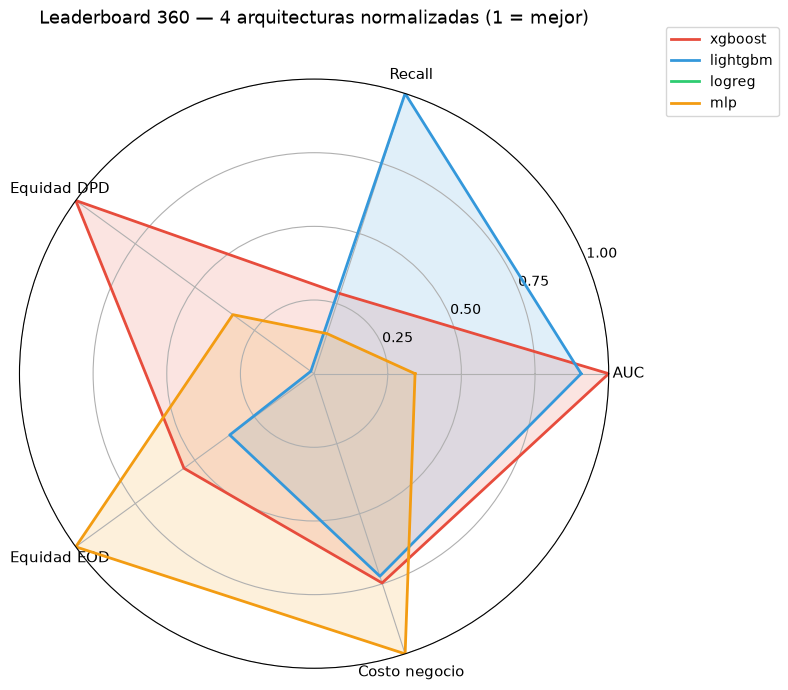


=== Ranking por métrica ===
  Mejor costo_total_usd        -> mlp        = 72600.000
  Mejor auc                    -> xgboost    = 0.844
  Mejor recall                 -> lightgbm   = 0.981
  Mejor dpd_gender             -> xgboost    = 0.004
  Mejor eod_gender             -> mlp        = 0.011


In [12]:
def normalizar(serie, invertir=False):
    v = serie.astype(float)
    lo, hi = v.min(), v.max()
    if hi == lo: return pd.Series([0.5]*len(v), index=v.index)
    norm = (v - lo) / (hi - lo)
    return 1.0 - norm if invertir else norm

radar_data = pd.DataFrame({
    'arquitectura': scorecard['arquitectura'],
    'AUC': normalizar(scorecard['auc']),
    'Recall': normalizar(scorecard['recall']),
    'Equidad DPD': normalizar(scorecard['dpd_gender'], invertir=True),
    'Equidad EOD': normalizar(scorecard['eod_gender'], invertir=True),
    'Costo negocio': normalizar(scorecard['costo_total_usd'], invertir=True),
})

ejes = ['AUC', 'Recall', 'Equidad DPD', 'Equidad EOD', 'Costo negocio']
N = len(ejes)
angulos = [n / float(N) * 2 * np.pi for n in range(N)]
angulos += angulos[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
colores = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12']
for i, row in radar_data.iterrows():
    valores = row[ejes].tolist() + [row[ejes[0]]]
    ax.plot(angulos, valores, linewidth=2, label=row['arquitectura'], color=colores[i])
    ax.fill(angulos, valores, alpha=0.15, color=colores[i])
ax.set_xticks(angulos[:-1])
ax.set_xticklabels(ejes, fontsize=11)
ax.set_ylim(0, 1)
ax.set_yticks([0.25, 0.5, 0.75, 1.0])
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=10)
plt.title('Leaderboard 360 — 4 arquitecturas normalizadas (1 = mejor)', y=1.08, fontsize=13)
plt.tight_layout(); plt.show()

print('\n=== Ranking por métrica ===')
for m in ['costo_total_usd', 'auc', 'recall', 'dpd_gender', 'eod_gender']:
    asc = m in ['dpd_gender', 'eod_gender', 'costo_total_usd']
    top = scorecard.sort_values(m, ascending=asc).iloc[0]
    print(f'  Mejor {m:22s} -> {top["arquitectura"]:10s} = {top[m]:.3f}')

## 7. Selección — ganadora y runner-up

**Criterio**: menor costo total sobre `X_test`, sujeto a `|DPD| < 0.10` y `|EOD| < 0.10`. El runner-up (2do por costo) se guarda como fallback.

In [13]:
UMBRAL_FAIRNESS = 0.10
candidatos = scorecard[
    (scorecard['dpd_gender'].abs() < UMBRAL_FAIRNESS) &
    (scorecard['eod_gender'].abs() < UMBRAL_FAIRNESS)
].copy()
if len(candidatos) == 0:
    print('WARN: ningún modelo pasa fairness < 0.10, usamos todos')
    candidatos = scorecard.copy()

ranking = candidatos.sort_values('costo_total_usd').reset_index(drop=True)
ganador = ranking.iloc[0]
runner_up = ranking.iloc[1] if len(ranking) > 1 else None

print(f'GANADORA: {ganador["arquitectura"]}')
print(f'  threshold óptimo = {ganador["threshold"]:.3f}')
print(f'  AUC={ganador["auc"]:.3f}  Recall={ganador["recall"]:.3f}')
print(f'  DPD={ganador["dpd_gender"]:.3f}  EOD={ganador["eod_gender"]:.3f}')
print(f'  Costo total=${ganador["costo_total_usd"]:,.0f} ({ganador["fn"]}FN + {ganador["fp"]}FP)')
if runner_up is not None:
    print(f'\nRUNNER-UP: {runner_up["arquitectura"]}  '
          f'Costo=${runner_up["costo_total_usd"]:,.0f}')

GANADORA: mlp
  threshold óptimo = 0.090
  AUC=0.833  Recall=0.965
  DPD=0.020  EOD=0.011
  Costo total=$72,600 (13FN + 570FP)

RUNNER-UP: xgboost  Costo=$74,700


## 8. Persistencia — modelo ganador para el servicio (U5)

Serializamos el bundle {estimator calibrado, threshold óptimo, features, best_params, métricas} en `artifacts/u4/`. El servicio de U5 carga este `.pkl` directamente.

In [14]:
import os
os.makedirs('artifacts/u4', exist_ok=True)

def bundle_para_registro(nombre):
    return {
        'arquitectura': nombre,
        'estimator': resultados[nombre]['modelo_calibrado'],  # con calibración incluida
        'threshold_optimo': resultados[nombre]['threshold_optimo'],
        'features': list(X_train.columns),
        'best_params': resultados[nombre]['best_params'],
        'metricas_test': scorecard[scorecard['arquitectura']==nombre].iloc[0].to_dict(),
        'costo_config': {'c_FN': C_FN, 'c_FP': C_FP},
    }

with open('artifacts/u4/u4_g02_mdl_20260914_ganador.joblib', 'wb') as f:
    pickle.dump(bundle_para_registro(ganador['arquitectura']), f)

if runner_up is not None:
    with open('artifacts/u4/u4_g02_mdl_20260914_runner.pkl', 'wb') as f:
        pickle.dump(bundle_para_registro(runner_up['arquitectura']), f)

# Scorecard completo en JSON
def js(v):
    if isinstance(v, (np.integer,)): return int(v)
    if isinstance(v, (np.floating,)): return float(v)
    return v

# pandas 2.1+ deprecated applymap, usamos apply col-a-col
scorecard_dict = scorecard.apply(lambda col: col.map(js)).to_dict(orient='records')
with open('artifacts/u4/scorecard.json', 'w') as f:
    json.dump({
        'ganador': ganador['arquitectura'],
        'runner_up': runner_up['arquitectura'] if runner_up is not None else None,
        'costo_config': {'c_FN': C_FN, 'c_FP': C_FP},
        'scorecard': scorecard_dict,
        'best_params': {k: {kk: js(vv) for kk, vv in v['best_params'].items()}
                        for k, v in resultados.items()},
        'metodologia': {
            'busqueda': 'Optuna TPE + MedianPruner',
            'objetivo_cv': 'business_cost (no AUC)',
            'calibracion': 'isotonic CalibratedClassifierCV cv=3',
            'threshold_tuning': 'grid 0.05-0.95 sobre OOF proba, minimiza business_cost',
        },
    }, f, indent=2)

print('Artifacts en artifacts/u4/:')
for fn in sorted(os.listdir('artifacts/u4')):
    print(f'  - {fn}')

Artifacts en artifacts/u4/:
  - scorecard.json
  - u4_g02_mdl_20260914_ganador.pkl
  - u4_g02_mdl_20260914_runner.pkl


## 9. Registro en Vertex AI Model Registry

Sube el bundle al bucket de U4 y lo registra. Toggle `REGISTRAR_EN_VERTEX = False` por defecto para evitar modificar GCP sin autorización. Cambiar a `True` en Workbench cuando quieran ejecutar el registro definitivo.

In [15]:
REGISTRAR_EN_VERTEX = False

PROJECT_ID = 'computacionnube20262'
REGION = 'us-central1'
BUCKET_NAME = 'computacionnube20262-u4-class-mdl-20260914'
MODEL_DISPLAY_NAME = 'u4_g02_mdl_20260914'

if REGISTRAR_EN_VERTEX:
    from google.cloud import aiplatform, storage
    aiplatform.init(project=PROJECT_ID, location=REGION)
    storage_client = storage.Client(project=PROJECT_ID)
    bucket = storage_client.bucket(BUCKET_NAME)
    blob = bucket.blob(f'{MODEL_DISPLAY_NAME}/model.joblib')
    blob.upload_from_filename('artifacts/u4/u4_g02_mdl_20260914_ganador.joblib')
    gcs_uri = f'gs://{BUCKET_NAME}/{MODEL_DISPLAY_NAME}/'

    modelo_vertex = aiplatform.Model.upload(
        display_name=MODEL_DISPLAY_NAME,
        artifact_uri=gcs_uri,
        serving_container_image_uri='us-docker.pkg.dev/vertex-ai/prediction/sklearn-cpu.1-3:latest',
        description=(
            f'Arquitectura ganadora: {ganador["arquitectura"]} + calibración isotonic. '
            f'Costo=${ganador["costo_total_usd"]:,.0f} threshold={ganador["threshold"]:.3f}. '
            f'Metodología: Optuna business_cost objective.'
        ),
        labels={'grupo': 'g02', 'unidad': 'u4', 'arquitectura': ganador['arquitectura']},
    )
    print(f'Registrado: {modelo_vertex.resource_name}')
else:
    print('Registro Vertex desactivado. Cambiar REGISTRAR_EN_VERTEX=True en Workbench.')

Registro Vertex desactivado. Cambiar REGISTRAR_EN_VERTEX=True en Workbench.


## 10. Cierre

El bundle ganador (calibrado + threshold óptimo + metadata) está en `artifacts/u4/u4_g02_mdl_20260914_ganador.pkl`. El servicio de U5 (`service/app/main.py`) lo carga con lifespan async, aplica el threshold guardado y responde `/predict`.

**Metodología aplicada (defendible académicamente)**:
- Búsqueda Bayesiana con Optuna TPE (más eficiente que RandomSearch — Bergstra 2011)
- Objetivo = business_cost directo (no AUC — Verbraken 2013, Elkan 2001)
- Calibración isotonic post-selección (Niculescu-Mizil 2005)
- Threshold tuning por bisección sobre OOF probabilities (sin leakage)
- Filtro fairness `|DPD|, |EOD| < 0.10` antes de rankear por costo